<a href="https://colab.research.google.com/github/Renad-Wael/ITI_Task/blob/main/0_0_cifar10_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


In [33]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [34]:
train_images.shape

(60000, 28, 28)

In [35]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [36]:
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

In [37]:
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

In [38]:
print("Train images shape:", train_images.shape)
print("Test images shape:", test_images.shape)

Train images shape: (60000, 28, 28, 1)
Test images shape: (10000, 28, 28, 1)


In [39]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

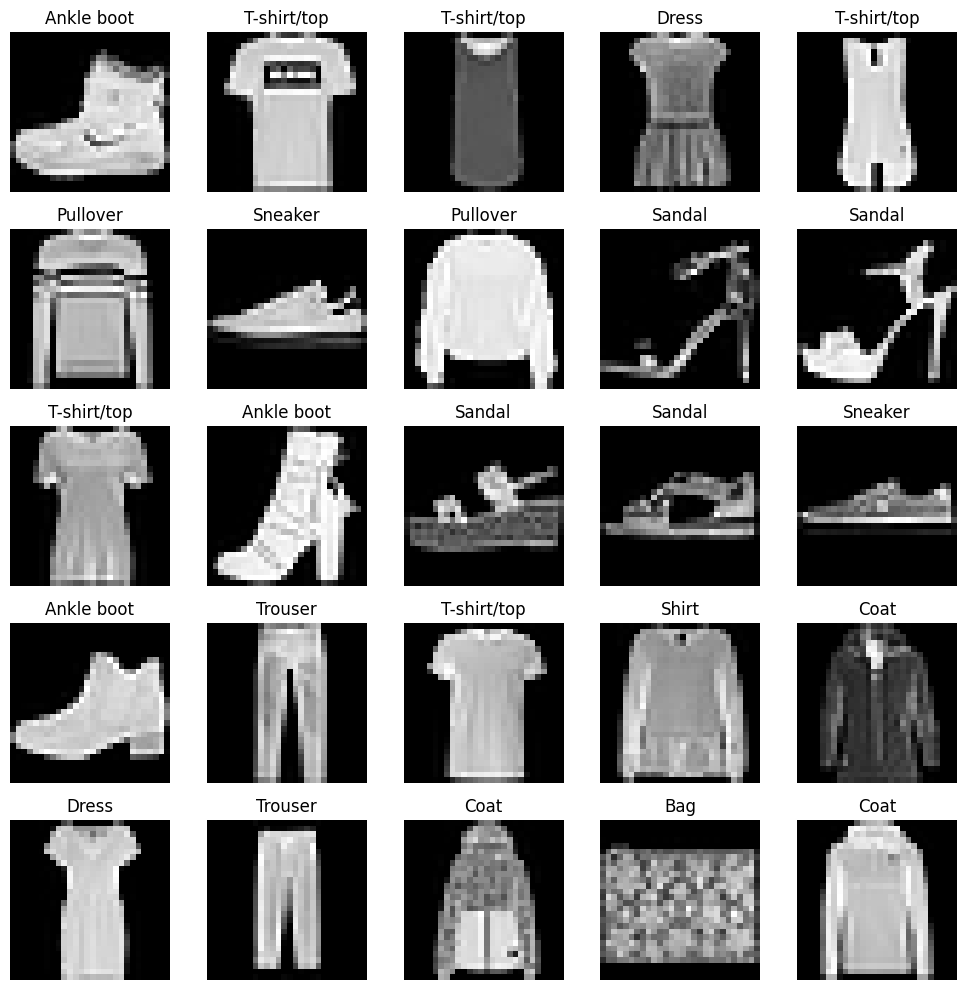

In [40]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [41]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

In [42]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.1,
    batch_size=128
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7940 - loss: 0.5738 - val_accuracy: 0.8482 - val_loss: 0.4137
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8674 - loss: 0.3713 - val_accuracy: 0.8790 - val_loss: 0.3481
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8824 - loss: 0.3246 - val_accuracy: 0.8797 - val_loss: 0.3293
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8959 - loss: 0.2899 - val_accuracy: 0.8940 - val_loss: 0.2961
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9011 - loss: 0.2670 - val_accuracy: 0.8950 - val_loss: 0.2901
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9101 - loss: 0.2451 - val_accuracy: 0.9055 - val_loss: 0.2631
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9167 - loss: 0.2271 - val_accuracy: 0.8965 - val_loss: 0.2874
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9231 - loss: 0.2109 - val_accuracy: 0

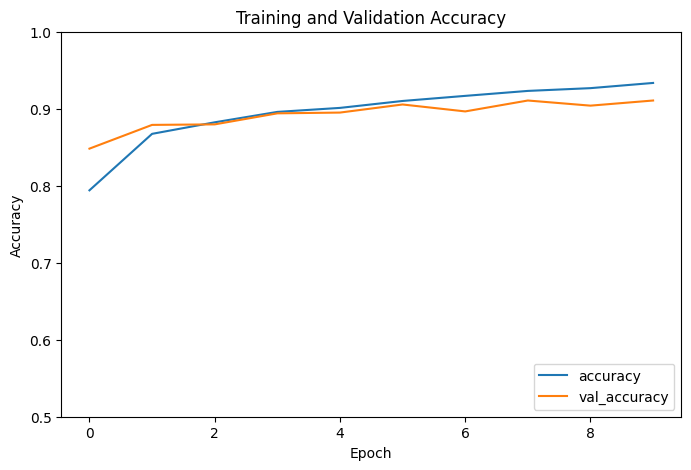

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='val_accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.ylim([0.5, 1])

plt.legend(loc='lower right')

plt.title('Training and Validation Accuracy')

plt.show()

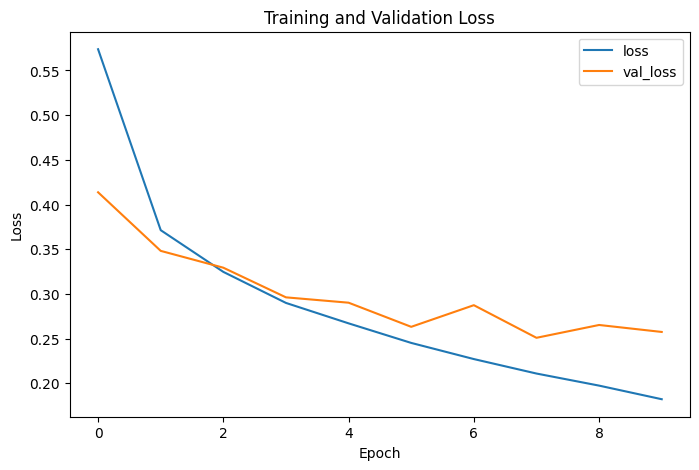

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='loss'
)

plt.plot(
    history.history['val_loss'],
    label='val_loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(loc='upper right')

plt.title('Training and Validation Loss')

plt.show()

In [47]:
test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    verbose=2
)

print("Test accuracy:", test_acc)

313/313 - 2s - 5ms/step - accuracy: 0.9061 - loss: 0.2653
Test accuracy: 0.9060999751091003


In [48]:
predictions = model.predict(
    test_images[5000:5005],
    verbose=0
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

for i in range(5):
    print(
        "Predicted:",
        class_names[predicted_classes[i]],
        "| Actual:",
        class_names[test_labels[5000 + i]]
    )

Predicted: Pullover | Actual: Pullover
Predicted: Dress | Actual: Dress
Predicted: Shirt | Actual: Shirt
Predicted: Coat | Actual: Coat
Predicted: Shirt | Actual: Shirt


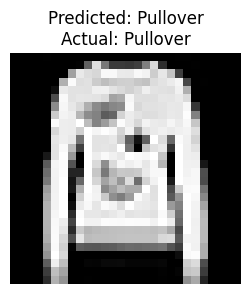

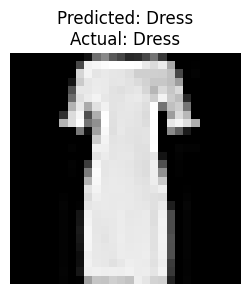

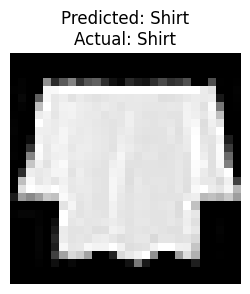

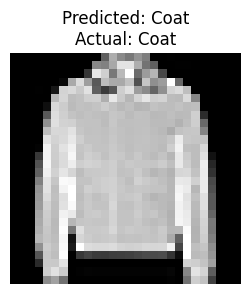

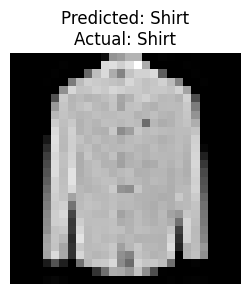

In [49]:
for i in range(5000, 5005):

    sample = test_images[i]

    prediction = model.predict(
        sample[np.newaxis, ...],
        verbose=0
    )

    predicted_label = np.argmax(
        prediction[0]
    )

    plt.figure(figsize=(3, 3))

    plt.imshow(
        sample.reshape(28, 28),
        cmap='gray'
    )

    plt.title(
        "Predicted: {}\nActual: {}".format(
            class_names[predicted_label],
            class_names[test_labels[i]]
        )
    )

    plt.axis('off')
    plt.show()